build me a funciton that determines the time distribution spent on all of the questions togethre on average. Then build me one on the first 5 questions. THen build me one on all the questions that were answered correctly vs all the ones that were not answered correctly

[PROGRESS]   0.00% | Starting data load

[HEAD] train split 1_2
       QuestionId  UserId  AnswerId  IsCorrect task_split
2439            0    6168  10728192          0        1_2
17792           2   40168    518165          1        1_2
34747           2   13932   6895610          1        1_2
36727           4   19710  12794582          1        1_2
47335           1   65813   5146272          1        1_2
rows: 2,535
[PROGRESS]  10.00% | Loaded train_task_1_2.csv (2,535 rows after filters)

[HEAD] train split 3_4
     QuestionId  UserId  AnswerId  IsCorrect task_split
535           3    3450    855444          1        3_4
561           4    2851    507646          1        3_4
570           4    1076   1109301          1        3_4
572           0    4726    282545          1        3_4
580           2    4410   1308406          1        3_4
rows: 9,515
[PROGRESS]  20.00% | Loaded train_task_3_4.csv (9,515 rows after filters)
[PROGRESS]  25.00% | Prepared AnswerId filters (1_2=2,53

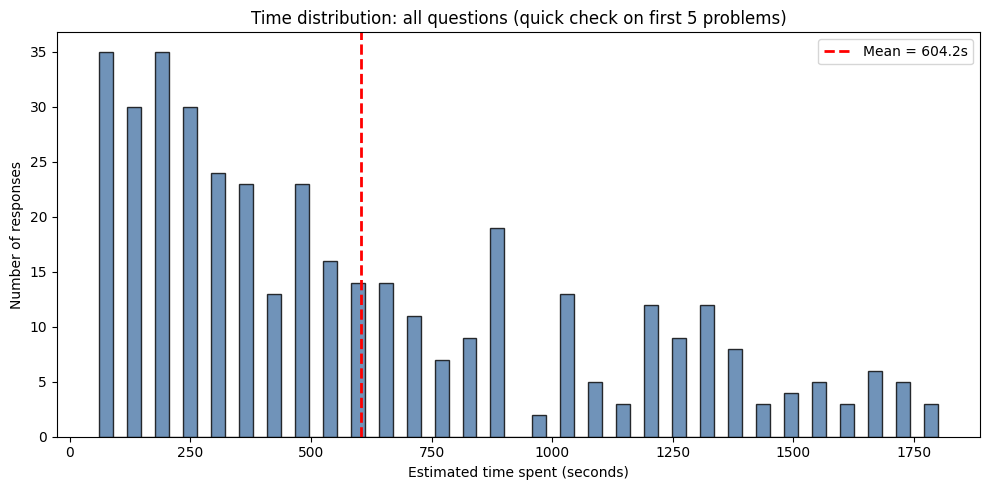

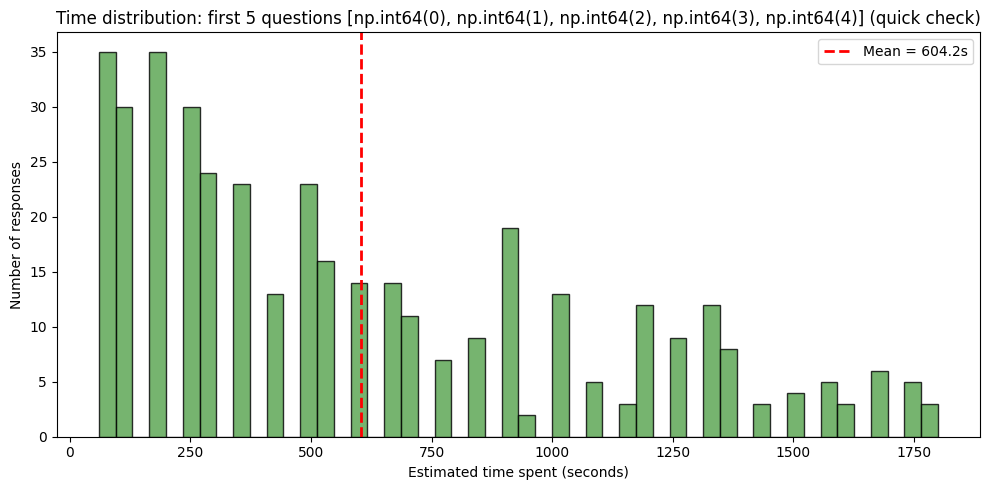

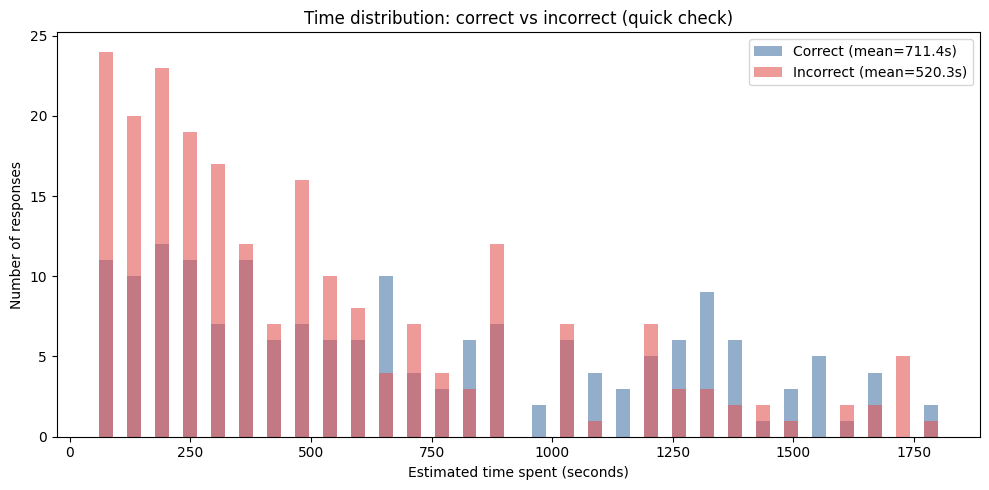

,group,n,mean_seconds,median_seconds
0,all,396,604.242424,480.0
1,first_5_questions,396,604.242424,480.0
2,correct,174,711.379310,630.0
3,incorrect,222,520.270270,360.0


In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


TRAIN_COLS = ["QuestionId", "UserId", "AnswerId", "IsCorrect"]
META_COLS = ["AnswerId", "DateAnswered"]


def _print_progress(percent: float, message: str) -> None:
    pct = max(0.0, min(100.0, float(percent)))
    print(f"[PROGRESS] {pct:6.2f}% | {message}")


def _count_data_rows(path: Path) -> int:
    """Fast-ish row count using newline scan (for percentage denominator)."""
    line_count = 0
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            line_count += block.count(b"\n")
    # subtract header row
    return max(0, line_count - 1)


def _load_train_split(
    path: Path,
    task_split: str,
    only_question_ids=None,
    show_head: bool = False,
) -> pd.DataFrame:
    df = pd.read_csv(path, usecols=TRAIN_COLS)
    df["task_split"] = task_split
    df = df[df["AnswerId"].notna()].copy()
    df["AnswerId"] = df["AnswerId"].astype("int64")

    if only_question_ids is not None:
        q_set = set(int(x) for x in only_question_ids)
        df = df[df["QuestionId"].isin(q_set)].copy()

    if show_head:
        print(f"\n[HEAD] train split {task_split}")
        print(df.head())
        print(f"rows: {len(df):,}")

    return df


def _load_answer_meta_split_chunked(
    path: Path,
    task_split: str,
    keep_answer_ids: set[int] | None = None,
    chunksize: int = 250_000,
    show_head: bool = False,
    start_percent: float = 0.0,
    end_percent: float = 100.0,
) -> pd.DataFrame:
    """Read answer metadata in chunks and print percentage progress."""
    frames = []
    matched_rows = 0

    total_rows = _count_data_rows(path)
    total_chunks = max(1, math.ceil(total_rows / chunksize))

    _print_progress(start_percent, f"Start loading {path.name} ({total_rows:,} rows)")

    reader = pd.read_csv(path, usecols=META_COLS, chunksize=chunksize)
    for i, chunk in enumerate(reader, start=1):
        chunk = chunk[chunk["AnswerId"].notna()].copy()
        chunk["AnswerId"] = chunk["AnswerId"].astype("int64")

        if keep_answer_ids is not None:
            chunk = chunk[chunk["AnswerId"].isin(keep_answer_ids)].copy()

        if not chunk.empty:
            frames.append(chunk)
            matched_rows += len(chunk)

        local_frac = min(1.0, i / total_chunks)
        pct = start_percent + (end_percent - start_percent) * local_frac
        _print_progress(
            pct,
            f"{path.name}: chunk {i}/{total_chunks}, matched rows={matched_rows:,}",
        )

    if frames:
        df = pd.concat(frames, ignore_index=True)
    else:
        df = pd.DataFrame(columns=META_COLS)

    df["task_split"] = task_split
    df = df.sort_values("DateAnswered").drop_duplicates(["AnswerId", "task_split"], keep="last")

    if show_head:
        print(f"\n[HEAD] answer metadata split {task_split}")
        print(df.head())
        print(f"rows: {len(df):,}")

    return df


def get_first_5_question_ids(base_data_dir: str = "../../data") -> list[int]:
    base = Path(base_data_dir)
    q1 = pd.read_csv(base / "train_data" / "train_task_1_2.csv", usecols=["QuestionId"])
    q2 = pd.read_csv(base / "train_data" / "train_task_3_4.csv", usecols=["QuestionId"])
    first_5 = sorted(pd.concat([q1, q2], ignore_index=True)["QuestionId"].dropna().unique())[:5]
    return [int(x) for x in first_5]


def load_response_data(
    base_data_dir: str = "../../data",
    only_question_ids=None,
    show_heads: bool = False,
    chunksize: int = 250_000,
) -> pd.DataFrame:
    base = Path(base_data_dir)

    _print_progress(0, "Starting data load")

    # 1) responses
    train_1_2 = _load_train_split(
        base / "train_data" / "train_task_1_2.csv", "1_2", only_question_ids, show_head=show_heads
    )
    _print_progress(10, f"Loaded train_task_1_2.csv ({len(train_1_2):,} rows after filters)")

    train_3_4 = _load_train_split(
        base / "train_data" / "train_task_3_4.csv", "3_4", only_question_ids, show_head=show_heads
    )
    _print_progress(20, f"Loaded train_task_3_4.csv ({len(train_3_4):,} rows after filters)")

    ids_1_2 = set(train_1_2["AnswerId"].unique())
    ids_3_4 = set(train_3_4["AnswerId"].unique())
    _print_progress(25, f"Prepared AnswerId filters (1_2={len(ids_1_2):,}, 3_4={len(ids_3_4):,})")

    # 2) metadata (with % by chunk)
    answer_meta_1_2 = _load_answer_meta_split_chunked(
        base / "metadata" / "answer_metadata_task_1_2.csv",
        "1_2",
        keep_answer_ids=ids_1_2,
        chunksize=chunksize,
        show_head=show_heads,
        start_percent=25,
        end_percent=60,
    )

    answer_meta_3_4 = _load_answer_meta_split_chunked(
        base / "metadata" / "answer_metadata_task_3_4.csv",
        "3_4",
        keep_answer_ids=ids_3_4,
        chunksize=chunksize,
        show_head=show_heads,
        start_percent=60,
        end_percent=90,
    )

    # 3) merge per split
    merged_1_2 = train_1_2.merge(
        answer_meta_1_2[["AnswerId", "DateAnswered", "task_split"]],
        on=["AnswerId", "task_split"],
        how="left",
        validate="many_to_one",
    )
    _print_progress(95, "Merged split 1_2")

    merged_3_4 = train_3_4.merge(
        answer_meta_3_4[["AnswerId", "DateAnswered", "task_split"]],
        on=["AnswerId", "task_split"],
        how="left",
        validate="many_to_one",
    )

    out = pd.concat([merged_1_2, merged_3_4], ignore_index=True)

    if show_heads:
        print("\n[HEAD] merged responses")
        print(out.head())
        print(f"rows: {len(out):,}")

    _print_progress(100, f"Response data ready ({len(out):,} rows)")
    return out


def add_time_spent_seconds(df: pd.DataFrame, max_gap_minutes: int = 30, show_head: bool = False) -> pd.DataFrame:
    _print_progress(0, "Computing time deltas")

    out = df.copy()
    out["DateAnswered"] = pd.to_datetime(out["DateAnswered"], errors="coerce")
    out = out.dropna(subset=["DateAnswered"]).copy()
    _print_progress(35, f"Parsed timestamps and dropped missing ({len(out):,} rows)")

    out = out.sort_values(["UserId", "DateAnswered"])
    _print_progress(65, "Sorted by user and timestamp")

    out["time_spent_seconds"] = out.groupby("UserId")["DateAnswered"].diff().dt.total_seconds()
    _print_progress(85, "Calculated per-user time differences")

    max_gap_seconds = max_gap_minutes * 60
    out.loc[
        (out["time_spent_seconds"] <= 0) | (out["time_spent_seconds"] > max_gap_seconds),
        "time_spent_seconds",
    ] = pd.NA

    if show_head:
        print("\n[HEAD] with time_spent_seconds")
        print(out.head())
        print(f"rows after DateAnswered cleanup: {len(out):,}")

    _print_progress(100, "Time feature ready")
    return out


def plot_time_distribution_all_questions(df: pd.DataFrame, bins: int = 60, title_suffix: str = "") -> None:
    s = df["time_spent_seconds"].dropna()
    plt.figure(figsize=(10, 5))
    plt.hist(s, bins=bins, color="#4c78a8", edgecolor="black", alpha=0.8)
    plt.axvline(s.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {s.mean():.1f}s")
    plt.title(f"Time distribution: all questions{title_suffix}")
    plt.xlabel("Estimated time spent (seconds)")
    plt.ylabel("Number of responses")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_time_distribution_first_5_questions(df: pd.DataFrame, bins: int = 50, title_suffix: str = "") -> None:
    first_5 = sorted(df["QuestionId"].dropna().unique())[:5]
    subset = df[df["QuestionId"].isin(first_5)]["time_spent_seconds"].dropna()
    plt.figure(figsize=(10, 5))
    plt.hist(subset, bins=bins, color="#54a24b", edgecolor="black", alpha=0.8)
    plt.axvline(subset.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {subset.mean():.1f}s")
    plt.title(f"Time distribution: first 5 questions {first_5}{title_suffix}")
    plt.xlabel("Estimated time spent (seconds)")
    plt.ylabel("Number of responses")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_time_distribution_correct_vs_incorrect(df: pd.DataFrame, bins: int = 60, title_suffix: str = "") -> None:
    correct = df[df["IsCorrect"] == 1]["time_spent_seconds"].dropna()
    incorrect = df[df["IsCorrect"] == 0]["time_spent_seconds"].dropna()

    plt.figure(figsize=(10, 5))
    plt.hist(correct, bins=bins, alpha=0.6, label=f"Correct (mean={correct.mean():.1f}s)", color="#4c78a8")
    plt.hist(incorrect, bins=bins, alpha=0.6, label=f"Incorrect (mean={incorrect.mean():.1f}s)", color="#e45756")
    plt.title(f"Time distribution: correct vs incorrect{title_suffix}")
    plt.xlabel("Estimated time spent (seconds)")
    plt.ylabel("Number of responses")
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_groups(df: pd.DataFrame) -> pd.DataFrame:
    first_5_ids = sorted(df["QuestionId"].dropna().unique())[:5]
    return pd.DataFrame(
        {
            "group": ["all", "first_5_questions", "correct", "incorrect"],
            "n": [
                df["time_spent_seconds"].notna().sum(),
                df[df["QuestionId"].isin(first_5_ids)]["time_spent_seconds"].notna().sum(),
                df[df["IsCorrect"] == 1]["time_spent_seconds"].notna().sum(),
                df[df["IsCorrect"] == 0]["time_spent_seconds"].notna().sum(),
            ],
            "mean_seconds": [
                df["time_spent_seconds"].mean(),
                df[df["QuestionId"].isin(first_5_ids)]["time_spent_seconds"].mean(),
                df[df["IsCorrect"] == 1]["time_spent_seconds"].mean(),
                df[df["IsCorrect"] == 0]["time_spent_seconds"].mean(),
            ],
            "median_seconds": [
                df["time_spent_seconds"].median(),
                df[df["QuestionId"].isin(first_5_ids)]["time_spent_seconds"].median(),
                df[df["IsCorrect"] == 1]["time_spent_seconds"].median(),
                df[df["IsCorrect"] == 0]["time_spent_seconds"].median(),
            ],
        }
    )


# Fast check first: first 5 problems only, with heads + percentage progress prints
first_5_ids = get_first_5_question_ids("../../data")
raw_df_5 = load_response_data(
    "../../data",
    only_question_ids=first_5_ids,
    show_heads=True,
    chunksize=250_000,
)
time_df_5 = add_time_spent_seconds(time_df_5 if 'time_df_5' in globals() else raw_df_5, max_gap_minutes=30, show_head=True)

plot_time_distribution_all_questions(time_df_5, title_suffix=" (quick check on first 5 problems)")
plot_time_distribution_first_5_questions(time_df_5, title_suffix=" (quick check)")
plot_time_distribution_correct_vs_incorrect(time_df_5, title_suffix=" (quick check)")

summarize_groups(time_df_5)

[PROGRESS]   0.00% | Starting data load

[HEAD] train split 1_2
   QuestionId  UserId  AnswerId  IsCorrect task_split
0       16997   65967  12453206          0        1_2
1       16531   62121  15686710          1        1_2
2       15911   50013  13598796          0        1_2
3        1701  104909  10511925          0        1_2
4       22896   21748    941747          0        1_2
rows: 15,867,850
[PROGRESS]  10.00% | Loaded train_task_1_2.csv (15,867,850 rows after filters)

[HEAD] train split 3_4
   QuestionId  UserId  AnswerId  IsCorrect task_split
0         898    2111    280203          1        3_4
1         767    3062     55638          1        3_4
2         165    1156    386475          1        3_4
3         490    1653    997498          1        3_4
4         298    3912    578636          1        3_4
rows: 1,382,727
[PROGRESS]  20.00% | Loaded train_task_3_4.csv (1,382,727 rows after filters)
[PROGRESS]  25.00% | Prepared AnswerId filters (1_2=15,867,850, 3_4=1,382,

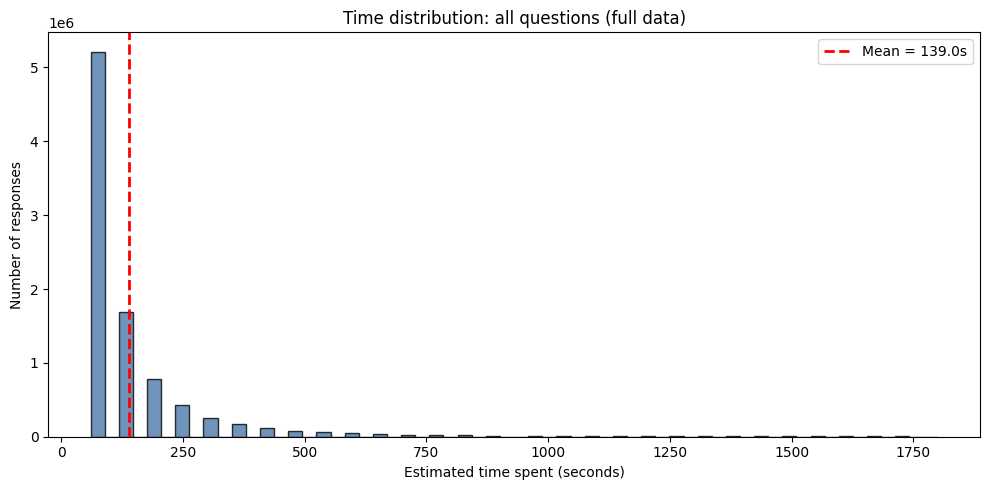

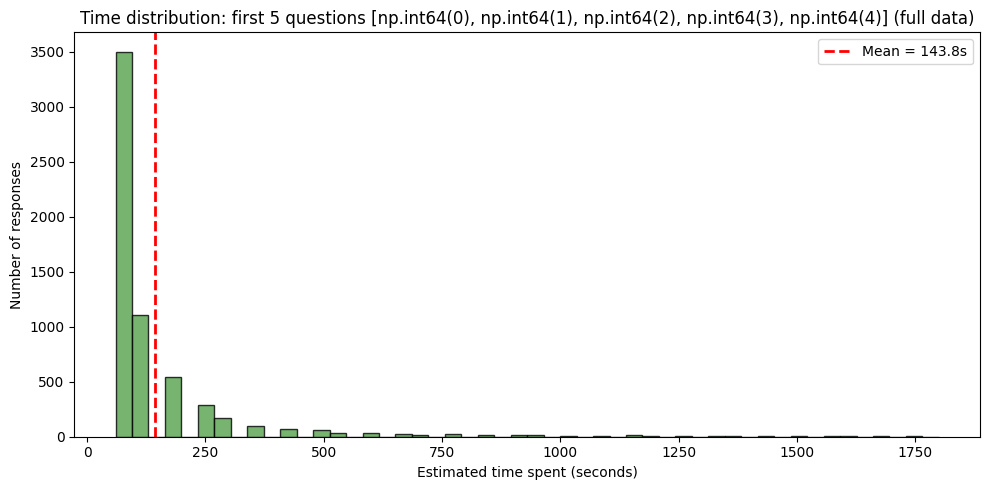

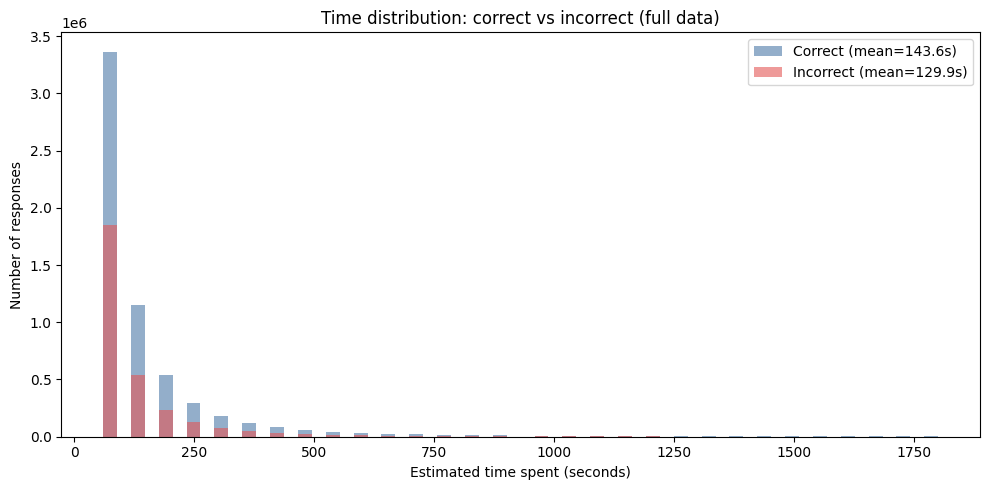

,group,n,mean_seconds,median_seconds
0,all,9054174,139.026526,60.0
1,first_5_questions,6099,143.797344,60.0
2,correct,6033858,143.602501,60.0
3,incorrect,3020316,129.884840,60.0


In [7]:
# Full-data run (slower): execute this after Cell 2 looks good
# You will see chunk progress logs while metadata is loading.
raw_df_all = load_response_data(
    "../../data",
    only_question_ids=None,
    show_heads=True,
    chunksize=300_000,
)
time_df_all = add_time_spent_seconds(raw_df_all, max_gap_minutes=30, show_head=True)

plot_time_distribution_all_questions(time_df_all, title_suffix=" (full data)")
plot_time_distribution_first_5_questions(time_df_all, title_suffix=" (full data)")
plot_time_distribution_correct_vs_incorrect(time_df_all, title_suffix=" (full data)")

summarize_groups(time_df_all)